# DataFrames para Pesquisa em Economia e Ciências Sociais

Prof. Daniel de Abreu Pereira Uhr

### Conteúdo

* Estrutura dos Dados 
  * Introdução
  * DataFrames - Séries Temporais
  * DataFrames - Cross-Sectional
  * DataFrames - Dados em Painel
* Raspagem de Dados da Web (*Web Scraping*)
  * Raspagem com o Pandas
  * Raspagem/Automação com o Selenium
* APIs - Application Programming Interface
  * Introdução
  * WoldBank Open Data
  * *Base dos Dados* - Gov. Brasil
  * API do IBGE - ex. malhas geográficas
  * NASA - Night 
* Outras Formas de Acesso à Microdados Oficiais do Brasil
  * RAIS - Relação Anual de Informações Sociais
  * Censo Demográfico - IBGE



### Referências

* Géron, Aurélien. Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems. O'Reilly Media, 2019.
* Athey, S., & Imbens, G. (2017). "The State of Applied Econometrics: Causality and Policy Evaluation." *Journal of Economic Perspectives*.
* Mullainathan, S., & Spiess, J. (2017). "Machine Learning: An Applied Econometric Approach." *Journal of Economic Perspectives*.
* Varian, H. R. (2014). "Big Data: New Tricks for Econometrics." *Journal of Economic Perspectives*.
* **sklearn** (https://scikit-learn.org/stable/install.html)
* **statsmodels** (https://www.statsmodels.org/stable/index.html)
* **Prophet** (https://facebook.github.io/prophet/docs/quick_start.html)
* **pmdarima** (https://alkaline-ml.com/pmdarima/)
* **darts** (https://unit8co.github.io/darts/)
* **gluonts** (https://ts.gluon.ai/stable/), [tslearn](https://tslearn.readthedocs.io/en/stable/)
* **tslearn** (https://tslearn.readthedocs.io/en/stable/)


## Estrutura dos Dados

### Introdução

Em econometria e ciência de dados aplicados à economia, é fundamental compreender a estrutura dos dados que estamos analisando. A forma como os dados estão organizados influencia diretamente:

* O tipo de modelo estatístico que podemos aplicar;
* As hipóteses que podem ser testadas;
* As limitações na inferência causal.

Os três principais tipos de estrutura de dados são:

* **Séries Temporais (Time Series)**
* **Dados em Seção Cruzada (Cross-sectional)**
* **Dados em Painel (Panel Data)**

### DataFrames - Séries Temporais

**Definição**

Séries temporais são conjuntos de observações ordenadas no tempo. Em geral, os dados são univariados ou multivariados e possuem frequência temporal regular (diária, mensal, trimestral, anual etc.).

***Estrutura Típica em Python***

In [2]:
import pandas as pd
import numpy as np

# Simulação de série mensal
np.random.seed(42)
dates = pd.date_range(start='2010-01-01', periods=60, freq='M')
gdp = np.cumsum(np.random.normal(0.5, 0.3, size=60)) + 100
inflation = np.random.normal(3, 0.2, size=60)

df_ts = pd.DataFrame({
    'date': dates,
    'gdp': gdp,
    'inflation': inflation
}).set_index('date')

df_ts

C:\Users\johan\AppData\Local\Temp\ipykernel_37432\2758155185.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2010-01-01', periods=60, freq='M')


,gdp,inflation
date,,
2010-01-31,100.649014,2.904165
2010-02-28,101.107535,2.962868
2010-03-31,101.801842,2.778733
2010-04-30,102.758750,2.760759
2010-05-31,103.188504,3.162505
2010-06-30,103.618263,3.271248
2010-07-31,104.592027,2.985598
2010-08-31,105.322258,3.200707
2010-09-30,105.681415,3.072327


Repare que são informações de um único indivíduo (ou unidade de análise) ao longo do tempo.

***Vizualização da Série Temporal***

* Plotando a Série Temporal `df_ts['gdp']`

Vamos utilizar o índice do dataframe como eixo x e o valor do PIB como eixo y. Para isso, utilizamos a função `plot()` do matplotlib, que é uma biblioteca de visualização de dados em Python. 



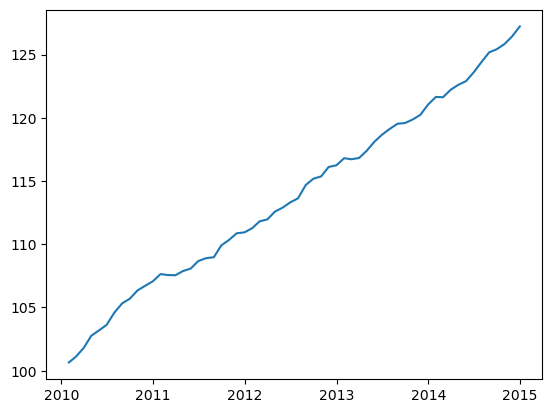

In [3]:
import matplotlib.pyplot as plt
plt.plot(df_ts.index, df_ts['gdp'])

* Plotando a série temporal `df_ts['inflation']`

Novamente, utilizamos o índice do dataframe como eixo x e o valor da inflação como eixo y. A função `plot()` do matplotlib é utilizada para criar o gráfico.

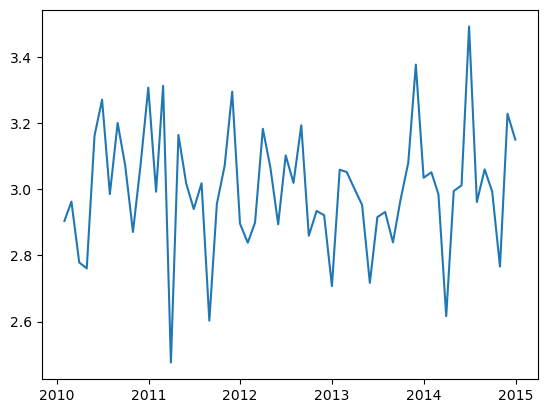

In [4]:
plt.plot(df_ts.index, df_ts['inflation'])

***Modelagem Econométrica de Séries Temporais***

Os dados de séries temporais acompanham a evolução de variáveis de um indivíduo (unidade de análise) ao longo do tempo. Por exemplo, o preço de fechamento de uma ação em cada dia do mês é uma série temporal; Ou o pib per capita de um país em cada ano.

Costuma-se modelar séries temporais como:

$$ Y_{t} = f(Y_{t-1}, Y_{t-2}, ..., Y_{t-n}) $$

Supondo que $Y_t$ seja a variável dependente, $Y_{t-1}$, $Y_{t-2}$, ..., $Y_{t-n}$ sejam as variáveis independentes e $f$ seja uma função que relaciona essas variáveis. Essa função pode ser linear ou não linear. Assumindo que a relação seja linear, podemos escrever:

$$ Y_t = \alpha + \beta_1 Y_{t-1} + \beta_2 Y_{t-2} + ... + \epsilon_t $$

repare que a variável dependente $Y_t$ possui um subscrito $t$ que indica o tempo, e a variável independente $Y_{t-1}$ possui um subscrito $t-1$ que indica o tempo anterior. Essa estrutura é típica de séries temporais, onde a variável dependente depende de seus próprios valores passados.

***Ideia prática***

O pesquisador que utiliza modelos de séries temporais costuma preocupar-se com medidas de ***grau de explicação do modelo***, como 
* o **R-quadrado**: medida que indica a proporção da variação da variável dependente que é explicada pelas variáveis independentes. Quanto maior o R-quadrado, melhor o modelo explica a variação da variável dependente.
* o **R-quadrado ajustado**: é uma versão do R-quadrado que leva em conta o número de variáveis independentes no modelo. O R-quadrado ajustado penaliza o uso de variáveis independentes que não contribuem significativamente para a explicação da variável dependente.
* **Erro Quadrático Médio (EQM)**: é uma medida que indica a média dos erros quadráticos entre os valores previstos pelo modelo e os valores reais da variável dependente. Quanto menor o EQM, melhor o modelo se ajusta aos dados.
* **Raiz do Erro Quadrático Médio (REQM)**: é a raiz quadrada do EQM. Essa medida é útil para interpretar o erro em unidades da variável dependente, facilitando a comparação entre diferentes modelos.
* **Erro Absoluto Médio (EAM)**: é a média dos erros absolutos entre os valores previstos pelo modelo e os valores reais da variável dependente. Quanto menor o EAM, melhor o modelo se ajusta aos dados.

O foco do pesquisador é em modelar a variável dependente de modo a prever seu comportamento futuro. Para isso, o pesquisador utiliza os dados passados da variável dependente e de outras variáveis independentes que possam influenciar seu comportamento. O modelo é ajustado aos dados históricos e, em seguida, utilizado para prever o comportamento futuro da variável dependente.

Para a análise dessa estrutura de base de dados, é usual o aprofundamento na teoria de séries temporais, que envolve conceitos como:

* Tendência
* Estacionariedade (ADF, KPSS)
* Sazonalidade
* Autocorrelação
* Heterocedasticidade

E a modelagem econométrica de séries temporais, que envolve a construção de modelos estatísticos para ***prever o comportamento futuro da variável e unidade de pesquisa em questão***. Esses modelos podem ser univariados ou multivariados, dependendo do número de variáveis envolvidas na análise. Por exemplo:

* Modelos ARIMA (AutoRegressive Integrated Moving Average)
* Modelos SARIMA (Seasonal ARIMA)
* Modelos VAR (Vector AutoRegressive)
* Modelos VEC (Vector Error Correction)
* Modelos GARCH (Generalized Autoregressive Conditional Heteroskedasticity)
* Modelos EGARCH (Exponential GARCH)
* Modelos VECM (Vector Error Correction Model)
* Modelos VECX (Vector Error Correction with eXogenous variables)
* Modelos VECMAX (Vector Error Correction Moving Average with eXogenous variables)
* entre outros.

***Desenvolvimento atual***

Atualmente, a literatura está se desenvolvendo a partir de modelos de aprendizado de máquina para séries temporais, que buscam capturar padrões complexos, não lineares nos dados e isolar efeitos causais em séries temporais. 

Esses modelos incluem:

* Prophet (Facebook)
* Random Forest / Extra Trees
* Gradient Boosting (XGBoost, LightGBM, CatBoost)
* Support Vector Regression (SVR)
* Deep Learning para Séries Temporais
  * RNN (Recurrent Neural Networks)
  * LSTM (Long Short-Term Memory) / GRU
  * Temporal Convolutional Networks (TCN)
  * Transformer (e variantes como Informer, Autoformer)

**Algumas bibliotecas python populares para previsão de séries temporais**

| Framework	| Modelos incluídos |
|------------------|------------------|
| [sklearn](https://scikit-learn.org/stable/install.html) |	RF, GB, SVR, Regressão |
| [statsmodels](https://www.statsmodels.org/stable/index.html) |	ARIMA, SARIMA, Holt-Winters|
| [Prophet](https://facebook.github.io/prophet/docs/quick_start.html) |	Tendência + Sazonalidade + Feriados |
| [pmdarima](https://alkaline-ml.com/pmdarima/) |	Auto ARIMA |
| [darts](https://unit8co.github.io/darts/) |	Interface única para ML, DL e ARIMA |
| [gluonts](https://ts.gluon.ai/stable/), [tslearn](https://tslearn.readthedocs.io/en/stable/) | 	Deep learning para séries temporais |

### DataFrames - Cross-Sectional

***Definição***

Dados observados em **um único ponto no tempo**, abrangendo **diferentes unidades** (indivíduos, empresas, países, etc.). Muito comuns em estudos de avaliação de impacto e análise de comportamento. Ou seja, é chamado de *Cross-Section, ou "seção cruzada" porque os dados são coletados em um único ponto no tempo, mas abrangem várias unidades de análise.



***Estrutura Típica em Python***

In [5]:
df_cs = pd.read_stata("https://github.com/Daniel-Uhr/data/raw/main/cattaneo2.dta")

# Criar a variável de resultado Y
df_cs['Y'] = df_cs['bweight']

# Criar a variável de tratamento 'Treated' com valor inicial de 0
df_cs['Treated'] = 0
# Recodificar a variável de tratamento 'Treated' para 1 se 'mbsmoke' for igual a 'smoker'
df_cs.loc[df_cs['mbsmoke'] == 'smoker', 'Treated'] = 1

df_cs

,bweight,mmarried,mhisp,fhisp,foreign,alcohol,deadkids,mage,medu,fage,...,mbsmoke,mrace,frace,prenatal,birthmonth,lbweight,fbaby,prenatal1,Y,Treated
0,3459,married,0,0,0,0,0,24,14,28,...,nonsmoker,1,1,1,12,0,No,Yes,3459,0
1,3260,notmarried,0,0,1,0,0,20,10,0,...,nonsmoker,0,0,1,7,0,No,Yes,3260,0
2,3572,married,0,0,1,0,0,22,9,30,...,nonsmoker,1,1,1,3,0,No,Yes,3572,0
3,2948,married,0,0,0,0,0,26,12,30,...,nonsmoker,1,1,1,1,0,No,Yes,2948,0
4,2410,married,0,0,0,0,0,20,12,21,...,nonsmoker,1,1,1,3,1,Yes,Yes,2410,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4637,3317,notmarried,0,0,0,0,0,21,12,24,...,smoker,1,1,2,10,0,Yes,No,3317,1
4638,3030,married,0,0,0,1,1,30,12,23,...,smoker,1,1,2,2,0,No,No,3030,1
4639,2950,notmarried,0,0,0,0,0,23,12,0,...,nonsmoker,0,0,1,5,0,Yes,Yes,2950,0
4640,3969,married,0,0,0,0,0,23,12,25,...,nonsmoker,1,1,1,2,0,Yes,Yes,3969,0


***Vizualização de Cross-Sectional***

Vamos comparar o peso dos bebês entre gestantes fumantes e não fumantes.

<Axes: xlabel='Y', ylabel='Density'>

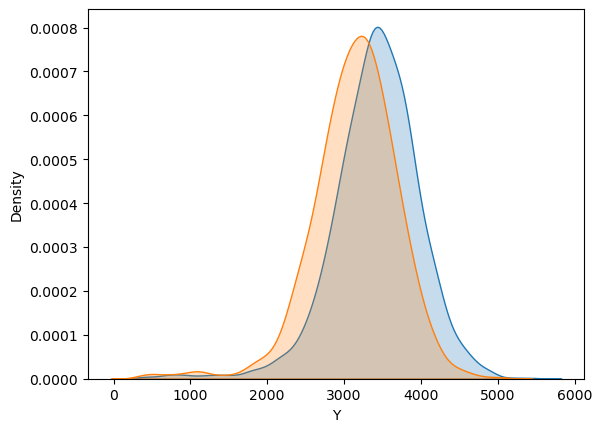

In [6]:
import seaborn as sns
sns.kdeplot(df_cs[df_cs['Treated'] == 0]['Y'], fill=True, label='Não fumantes')
sns.kdeplot(df_cs[df_cs['Treated'] == 1]['Y'], fill=True, label='Fumantes')

***Modelagem Econométrica de Dados Cross-Sectional***

Costuma-se modelar dados em seção cruzada como:

$$ Y_{i} = f(X_{i}) $$

onde $Y_{i}$ é a variável dependente, $X_{i}$ é um vetor de variáveis independentes e $f$ é uma função que relaciona essas variáveis. Essa função pode ser linear ou não linear. Assumindo que a relação seja linear, podemos escrever:

$$ Y_{i} = \alpha + \beta_1 X_{i1} + \beta_2 X_{i2} + ... + \epsilon_{i} $$

onde $X_{i1}$, $X_{i2}$, ... são as variáveis independentes e $\epsilon_{i}$ é o erro aleatório. Essa estrutura é típica de dados em seção cruzada, onde a variável dependente depende de um conjunto de variáveis independentes observadas em um único ponto no tempo.

Repare que a variável dependente $Y_{i}$ possui um subscrito $i$ que indica a unidade de análise, e as variáveis independentes $X_{i1}$, $X_{i2}$, ... também possuem subscritos $i$ que indicam a mesma unidade de análise. Essa estrutura é típica de dados em seção cruzada, onde as variáveis independentes são observadas em um único ponto no tempo para diferentes unidades de análise.

Normalmente, a modelagem econométrica de dados em seção cruzada envolve a construção de modelos estatísticos para:
* ***inferir relações causais entre variáveis e testar hipóteses***. 
  * Foco em uma relação específica entre $X_{j}$ e $Y_{i}$.
* Atenção para Heterocedasticidade
* Caso exista fonte de endogeneidade, é necessário técnicas que busquem lidar com isso. 

***Ideia prática***

O pesquisador que utiliza dados "cross-sectional" costuma utilizaros modelos de regressão linear com intuito de testar hipóteses e inferir relações causais entre grupos. Usualmente, compara-se grupos de indivíduos (empresas ou países) que tenham sofrido uma intervenção (ou tratamento) com grupos que não tenham sofrido essa intervenção. Essa comparação é feita para verificar se a intervenção teve um efeito significativo sobre a variável dependente. O pesquisador utiliza dados de diferentes unidades de análise em um único ponto no tempo para testar essas hipóteses e inferir relações causais entre variáveis.

Assim, a preocupação do pesquisador é focada nos testes de hipóteses (teste-t entre grupos) e tentativa de isolar o efeito causal (garantir a hipótese de exogeneidade estrita). 

### DataFrames - Dados em Painel

***Definição***

Dados observados em **diferentes pontos no tempo** e abrangendo **diferentes unidades** (indivíduos, empresas, países, etc.). Ou seja, é chamado de *Painel* porque os dados são coletados em diferentes pontos no tempo para diferentes unidades de análise. Essa estrutura permite analisar a evolução de variáveis ao longo do tempo e entre diferentes unidades de análise.

Também é chamado de *Longitudinal Data* ou *Time Series Cross-Sectional Data* (TSCS). Como possui duas dimensões (tempo e unidades), quando a dimensão do tempo é maior que a dimensão das unidades, é chamado de *Long Panel Data* (Painel Longo). Quando a dimensão das unidades é maior que a dimensão do tempo, é chamado de *Short Panel Data* (Painel Curto). Nos paineis Longos as características de séries temporais são mais relevantes, enquanto nos paineis Curtos as características de seção cruzada são mais relevantes.

***Estrutura Típica em Python***

In [7]:
import pandas as pd
df_pd = pd.read_stata("https://github.com/Daniel-Uhr/data/raw/main/bacon_example.dta")
df_pd

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
0,1,1964.0,1971.0,0.0,35.639885,12406.178537,5.007341,0.012312,1.715156e+06,1.715156e+06
1,1,1965.0,1971.0,0.0,41.543755,13070.206738,4.425367,0.010419,1.715156e+06,1.725186e+06
2,1,1966.0,1971.0,0.0,34.252335,13526.663217,4.874819,0.009900,1.715156e+06,1.735219e+06
3,1,1967.0,1971.0,0.0,34.465023,13918.189823,5.362014,0.009975,1.715156e+06,1.745250e+06
4,1,1968.0,1971.0,0.0,40.440105,14684.808682,4.643759,0.012401,1.715156e+06,1.755283e+06
...,...,...,...,...,...,...,...,...,...,...
1612,56,1992.0,1977.0,1.0,33.149574,31181.450546,1.970134,0.028996,1.621688e+05,2.323830e+05
1613,56,1993.0,1977.0,1.0,63.909775,31666.776231,3.020953,0.026672,1.621688e+05,2.355600e+05
1614,56,1994.0,1977.0,1.0,81.793816,31959.528356,3.501871,0.023643,1.621688e+05,2.389800e+05
1615,56,1995.0,1977.0,1.0,30.630585,32327.659531,0.740606,0.020965,1.621688e+05,2.414090e+05


A variável identificadora é `stfips`, que representa o estado, e a variável temporal é `year`, que representa o ano. 

É importante entendermos que os dados em painel costuma estar em formato "longo", ou seja, cada linha representa uma observação para uma unidade de análise em um determinado ponto no tempo. Isso significa que, para cada unidade de análise, teremos várias linhas correspondentes a diferentes períodos de tempo. Essa estrutura é fundamental para a análise de dados em painel, pois permite observar como as variáveis evoluem ao longo do tempo e entre diferentes unidades de análise.

In [8]:
n_individuos = df_pd['stfips'].nunique()
n_individuos

49

In [9]:
n_periodos = df_pd['year'].nunique()
n_periodos

33

Chamamos de ***painel balanceado*** aquele em que todas as unidades de análise possuem o mesmo número de observações. Já o painel ***não balanceado*** (desbalanceado) é aquele em que as unidades de análise possuem diferentes números de observações.

In [10]:
painel_balanceado = df_pd.groupby('stfips')['year'].nunique().nunique() == 1
painel_balanceado

True

Temos um painel balanceado, onde cada unidade de análise possui o mesmo número de observações.

***Modelagem Econométrica de Dados em Painel***

Costuma-se modelar dados em painel como:

$$ Y_{it} = f(X_{it}) $$

onde $Y_{it}$ é a variável dependente, $X_{it}$ é um vetor de variáveis independentes e $f$ é uma função que relaciona essas variáveis. Essa função pode ser linear ou não linear. Assumindo que a relação seja linear, podemos escrever:

$$ Y_{it} = \alpha + \beta_1 X_{it1} + \beta_2 X_{it2} + ... + \epsilon_{it} $$

onde $X_{it1}$, $X_{it2}$, ... são as variáveis independentes e $\epsilon_{it}$ é o erro aleatório. Essa estrutura é típica de dados em painel, onde a variável dependente depende de um conjunto de variáveis independentes observadas em diferentes pontos no tempo.

***Efeito fixo individual***

A estrutura de dados em painel é bastante importante na econometria, pois permite controlar os chamados efeitos fixos e/ou aleatórios, que são características não observadas pelo pesquisador que também podem influenciar a variável dependente. Em econometria o efeito fixo possui relevência especial porque pode ser fonte de viés de estimação. 

Por exemplo, em um estudo sobre o impacto da educação na renda, o efeito fixo pode representar características individuais não observadas, como habilidades inatas ou motivação. Modelamos o efeito fixo como uma variável independente (uma característica individual, constante no tempo), mas que não é observada diretamente. Assim, o modelo de dados em painel pode ser escrito como:

$$ Y_{it} = \beta_1 X_{it1} + \beta_2 X_{it2} + \mu_i + \epsilon_{it} $$

onde $\mu_i$ é o efeito fixo associado à unidade de análise $i$. Esses efeitos podem ser interpretados como características não observadas que afetam a variável dependente, mas que não estão incluídas no modelo. Por exemplo, em um estudo sobre o impacto da educação na renda, o efeito fixo pode representar características individuais não observadas, como habilidades inatas ou motivação.

*Observação*: a constante $\alpha$ é a média dos efeitos fixos, ou seja, $\alpha = \frac{1}{N} \sum_{i=1}^{N} \mu_i$, onde $N$ é o número de unidades de análise. Portanto, o efeito fixo individual é uma característica constante ao longo do tempo, mas que varia entre os indivíduos. Isso significa que cada indivíduo tem um efeito fixo diferente, que não pode ser observado diretamente, mas que afeta a variável dependente.

***Efeito fixo temporal***

O efeito fixo temporal é uma característica comum em dados em painel, onde a variável dependente é influenciada por fatores que variam ao longo do tempo, mas não entre os indivíduos. Esses fatores podem incluir mudanças econômicas, políticas ou sociais que afetam todos os indivíduos de maneira semelhante. O modelo de dados em painel pode ser escrito como:

$$ Y_{it} = \alpha + \beta_1 X_{it1} + \beta_2 X_{it2} + \mu_t + \epsilon_{it} $$

O efeito fixo temporal é representado por $\mu_t$, que captura as variações na variável dependente que ocorrem ao longo do tempo, mas não entre os indivíduos. Por exemplo, em um estudo sobre o impacto da educação na renda, o efeito fixo temporal pode representar mudanças econômicas que afetam todos os indivíduos de maneira semelhante, como uma recessão ou um boom econômico (ou seja, um choque comum).

***Two-way fixed effects - TWFE***

O modelo de efeitos fixos bidirecionais (two-way fixed effects) é uma extensão do modelo de efeitos fixos que considera tanto os efeitos fixos individuais quanto os efeitos fixos temporais. Esse modelo é útil quando se deseja controlar simultaneamente por características não observadas que variam entre os indivíduos e características não observadas que variam ao longo do tempo. O modelo pode ser escrito como:

$$ Y_{it} = \beta_1 X_{it1} + \beta_2 X_{it2} + \mu_i + \mu_t + \epsilon_{it} $$

onde $\mu_i$ representa os efeitos fixos individuais e $\mu_t$ representa os efeitos fixos temporais. Esse modelo é amplamente utilizado em estudos de avaliação de impacto e análise de comportamento, pois permite controlar simultaneamente por características não observadas que variam entre os indivíduos e características não observadas que variam ao longo do tempo.


## Raspagem de Dados da Web (*Web Scraping*)

### Introdução

Técnica de extração automatizada de dados de sites (conteúdo web), com o objetivo de coletar informações que não estão disponíveis em APIs (Application Programming Interfaces) ou em formatos estruturados (como CSV, JSON, etc.). Outra justificativa seria os dados que possuem atualizações contínuas, como preços de ações, taxas de câmbio, entre outros (Web crawlers).

* ***Web Scraper***: é específico, voltado para extrair dados de páginas alvo.

* ***Web crawlers***: spiders, bots ou web robots - são programas automatizados que navegam pela internet de forma sistemática, visitando páginas da web, seguindo links, e coletando informações.

Na prática, os dois podem trabalhar juntos:
* O crawler localiza as páginas,
* O scraper extrai as informações

### Raspagem com o Pandas

Vejamos uma forma de coletar as informações em tabelas de modo simples.

Fiz uma pesquisa sobre "PIB nominal per capita" no Google e encontrei o seguinte site: 
* https://pt.wikipedia.org/wiki/Lista_de_pa%C3%ADses_por_PIB_nominal_per_capita

Ao abrir o site, ele mostra algumas imagens e tabelas com dados sobre o PIB nominal per capita de vários países. O site possui uma formatação HTML. A tabela é uma estrutura de dados tabular que pode ser facilmente manipulada e analisada. Para coletar os dados dessa tabela, podemos carregá-la em um DataFrame do Pandas (de html para DataFrame). Ao carregá-la, podemos manipulá-la e analisá-la como quisermos.

**Rotina no Python**

In [11]:
import pandas as pd

In [12]:
# Raspagem das tabelas do Wikipedia
url = 'https://pt.wikipedia.org/wiki/Lista_de_pa%C3%ADses_por_PIB_nominal_per_capita'
df_list = pd.read_html(url)

# Checando o número de tabelas encontradas
print(len(df_list))

12


Temos 12 tabelas. Verificando o tamanho de cada tabela:

In [13]:
for df in df_list: print(df.shape)

(1, 2)
(1, 3)
(609, 3)
(192, 3)
(196, 3)
(216, 3)
(6, 2)
(10, 3)
(3, 2)
(4, 2)
(16, 2)
(5, 2)


Vamos olhar o conteúdo de cada uma delas.

In [14]:
# Verificando a primeira tabela
df_list[0].head()

,0,1
0,NaN,Este artigo ou seção pode conter informações d...


In [15]:
# Verificando a segunda tabela
df_list[1].head()

,0,1,2
0,">$60,000 $50,000 - $60,000 $40,000 - $50,000 $...","$20,000 - $30,000 $10,000 - $20,000 $5,000 - $...","$1,000 - $2,500 $500 - $1,000 <$500 Sem dados"


In [16]:
# Verificando a terceira tabela
df_list[2].head(10)

,0,1,2
0,Fundo Monetário Internacional (2024)[3],Banco Mundial (2019)[4],Nações Unidas (2018)[5]
1,Posição País/Território US$ 1 Luxemburgo 131....,Posição País/Território US$ 1 Mónaco[6] 190.5...,Posição País/Território US$ 1 Mónaco 185.835 ...
2,Posição,País/Território,US$
3,1,Luxemburgo,131.384
4,2,Irlanda,106.059
5,3,Suíça,105.669
6,4,Noruega,94.660
7,5,Singapura,88.447
8,6,Estados Unidos,85.373
9,7,Islândia,84.594


In [17]:
# Verificando a quarta tabela
df_list[3].head(10)

,Posição,País/Território,US$
0,1,Luxemburgo,131.384
1,2,Irlanda,106.059
2,3,Suíça,105.669
3,4,Noruega,94.660
4,5,Singapura,88.447
5,6,Estados Unidos,85.373
6,7,Islândia,84.594
7,8,Catar,81.400
8,—,Macau,78.962
9,9,Dinamarca,68.898


In [18]:
# Verificando a quinta tabela
df_list[4].head(10)

,Posição,País/Território,US$
0,1,Mónaco[6],190.512
1,2,Liechtenstein (2018)[6],180.366
2,3,Luxemburgo,114.705
3,—,Macau,84.096
4,4,Suíça,81.994
5,5,Irlanda,78.661
6,6,Noruega,75.420
7,7,Islândia,66.945
8,8,Estados Unidos,65.281
9,9,Singapura,65.233


In [19]:
# Verificando a sexta tabela
df_list[5].head(10)

,Posição,País/Território,US$
0,1,Mónaco,185.835
1,2,Liechtenstein,179.258
2,3,Luxemburgo,117.370
3,4,Bermudas,101.208
4,5,Macau,86.355
5,6,Ilhas Caimã,85.474
6,4,Suíça,82.709
7,5,Noruega,81.336
8,6,Irlanda,79.415
9,7,Islândia,76.867


As 3 tabelas que queríamos raspar são: `df_list[3]`, `df_list[4]` e `df_list[5]`.

In [20]:
tabela1 = df_list[3]
tabela2 = df_list[4]
tabela3 = df_list[5]

In [21]:
tabela1

,Posição,País/Território,US$
0,1,Luxemburgo,131.384
1,2,Irlanda,106.059
2,3,Suíça,105.669
3,4,Noruega,94.660
4,5,Singapura,88.447
...,...,...,...
187,181,Iêmen,486.000
188,182,Malawi,481.000
189,183,Afeganistão,422.000
190,183,Sudão do Sul,422.000


In [22]:
tabela2

,Posição,País/Território,US$
0,1,Mónaco[6],190.512
1,2,Liechtenstein (2018)[6],180.366
2,3,Luxemburgo,114.705
3,—,Macau,84.096
4,4,Suíça,81.994
...,...,...,...
191,185,Moçambique,492.000
192,186,República Centro-Africana,468.000
193,187,Sudão,442.000
194,188,Malawi,412.000


In [23]:
tabela3

,Posição,País/Território,US$
0,1,Mónaco,185.835
1,2,Liechtenstein,179.258
2,3,Luxemburgo,117.370
3,4,Bermudas,101.208
4,5,Macau,86.355
...,...,...,...
211,189,República Centro-Africana,481.000
212,190,Libéria,440.000
213,191,Malawi,397.000
214,192,Burundi,294.000


**Limpeza**

Primeiramente vamos ajustar os nomes das colunas de cada tabela para que o pib per capita em US Dólar sejá vinculado à fonte de dados específica.


In [24]:
tabela1.rename(columns={'US$': 'US$_FMI'}, inplace=True)
tabela2.rename(columns={'US$': 'US$_WB'}, inplace=True)
tabela3.rename(columns={'US$': 'US$_UN'}, inplace=True)

Repare que na tabela2, temos Mónaco[6], e precisamos retirar o termo `[6]`. Para isso, podemos usar a função `str.replace()` do Pandas. Como já sabemos, essa função substitui uma substring por outra em uma string. No caso, vamos substituir o `[6]` por vazio (ou seja, vamos removê-lo do string).

In [25]:
tabela2['País/Território'] = tabela2['País/Território'].str.replace(r'\s*\[.*?\]', '', regex=True)  # Remove colchetes

Significado de `r'\s*\[.*?\]'`:
* `r'...'`: O prefixo r significa "raw string" em Python. Isso diz ao interpretador para não escapar os caracteres especiais, ou seja, \n, \t, \[ etc. serão interpretados literalmente como \n, \t, \[, e não como nova linha, tabulação, etc.
* `\s*`: `\s` representa qualquer caractere de espaço em branco, como espaço, tabulação, nova linha. `*` significa "zero ou mais vezes". Isso pega espaços antes do colchete, se existirem.
* `\[` O colchete esquerdo `[` é um caractere especial em regex, então você precisa escapar com `\` logo `\[`.
* `.*?`: `.` Significa qualquer caractere (exceto nova linha). `*?` é uma forma de dizer "repita qualquer caractere zero ou mais vezes", mas pare assim que encontrar o próximo `]`.
* `\]`: Fecha o padrão com o colchete direito, `\]`.

In [26]:
tabela2

,Posição,País/Território,US$_WB
0,1,Mónaco,190.512
1,2,Liechtenstein (2018),180.366
2,3,Luxemburgo,114.705
3,—,Macau,84.096
4,4,Suíça,81.994
...,...,...,...
191,185,Moçambique,492.000
192,186,República Centro-Africana,468.000
193,187,Sudão,442.000
194,188,Malawi,412.000


Agora, vamos retirar os números entre parênteses, como em "Liechtenstein (2018)", queremos retirar o (2018). Para isso, podemos usar a função `str.replace()` novamente, mas agora com uma expressão regular diferente. A expressão regular `r'\s*\(.*?\)'` vai encontrar qualquer número entre parênteses e substituí-lo por nada.

In [27]:
tabela2['País/Território'] = tabela2['País/Território'].str.replace(r'\s*\(.*?\)', '', regex=True)  # Remove parênteses

In [28]:
tabela2

,Posição,País/Território,US$_WB
0,1,Mónaco,190.512
1,2,Liechtenstein,180.366
2,3,Luxemburgo,114.705
3,—,Macau,84.096
4,4,Suíça,81.994
...,...,...,...
191,185,Moçambique,492.000
192,186,República Centro-Africana,468.000
193,187,Sudão,442.000
194,188,Malawi,412.000


Vamos aplicar esses códigos para todas as tabelas.

In [29]:
tabela1['País/Território'] = tabela1['País/Território'].str.replace(r'\s*\(.*?\)', '', regex=True)  # Remove parênteses
tabela1['País/Território'] = tabela1['País/Território'].str.replace(r'\s*\[.*?\]', '', regex=True)  # Remove colchetes

In [30]:
tabela3['País/Território'] = tabela3['País/Território'].str.replace(r'\s*\(.*?\)', '', regex=True)  # Remove parênteses
tabela3['País/Território'] = tabela3['País/Território'].str.replace(r'\s*\[.*?\]', '', regex=True)  # Remove colchetes

**Criação de variável identificadora para os países**

Lembre que para juntarmos os bancos de dados em um único dataframe precisamos de uma variável identificadora. Para isso, vamos criar uma variável chamada `id` que será o código do país. Essa variável vai ser criada a partir da coluna `País/Território` de cada tabela.

**Passo 1:** Vamos empilhar a coluna dos nomes dos países `['País/Território']` em uma nova variável:

In [31]:
paises = pd.concat([tabela1['País/Território'], tabela2['País/Território'], tabela3['País/Território']], ignore_index=True)

vejamos o que temos:

In [32]:
paises

0                     Luxemburgo
1                        Irlanda
2                          Suíça
3                        Noruega
4                      Singapura
                 ...            
599    República Centro-Africana
600                      Libéria
601                       Malawi
602                      Burundi
603                      Somália
Name: País/Território, Length: 604, dtype: object

conseguimos empilhar as colunas das três tabelas, vamos ordenar os dados (repare que temos 604 países descritos na lista).

Agora vamos instalar `unidecode` para retirar os acentos dos nomes dos países (pode acontecer de existir acento em um banco, e noutro não). Para isso, execute o seguinte comando no terminal do Jupyter Notebook:

`!pip install unidecode`

Depois de instalado, podemos ordenar essa nova base para verificarmos se existem países repetidos. Para isso, vamos usar a função `sort_values()` do Pandas.

In [33]:
from unidecode import unidecode

# Ordenar dataframe ignorando acentos
paises = paises.sort_values(key=lambda x: x.apply(unidecode)).reset_index(drop=True)
paises

0        Afeganistão
1        Afeganistão
2        Afeganistão
3             África
4      África do Sul
           ...      
599           Zâmbia
600           Zâmbia
601         Zimbabwe
602         Zimbabwe
603         Zimbabwe
Name: País/Território, Length: 604, dtype: object

Agora, vamos aplicar a função `drop_duplicates()` para remover os duplicados. Assim, teremos uma ***lista de países únicos*** que podemos usar como identificador.

In [34]:
paises = paises.drop_duplicates().reset_index(drop=True)

In [35]:
paises

0        Afeganistão
1             África
2      África do Sul
3            Albânia
4           Alemanha
           ...      
214          Vanuatu
215        Venezuela
216         Vietname
217           Zâmbia
218         Zimbabwe
Name: País/Território, Length: 219, dtype: object

Certo, conseguimos uma lista com todos os países possíveis. Agora, vamos reorganizar o objeto `paises` em forma de DataFrame, com uma única coluna chamada 'País/Território', removendo o índice antigo. 

In [36]:
paises = pd.DataFrame({'País/Território': paises.reset_index(drop=True)})

Agora vamos criar uma variável identificadora para cada país. Para isso, vamos apenas criar uma nova coluna `ID`, que será uma contagem de 1 em diante.

In [37]:
paises['ID'] = range(1, len(paises) + 1)

ou seja, criamos uma coluna `ID` que vai de 1 até o número de linhas do dataframe (`len(paises)`) mais um.

In [38]:
paises

,País/Território,ID
0,Afeganistão,1
1,África,2
2,África do Sul,3
3,Albânia,4
4,Alemanha,5
...,...,...
214,Vanuatu,215
215,Venezuela,216
216,Vietname,217
217,Zâmbia,218


Vamos juntar esse identificador em todas as tabelas utilizando 'País/Território' como chave.

In [39]:
tabela1 = tabela1.merge(paises, on='País/Território', how='left')
tabela2 = tabela2.merge(paises, on='País/Território', how='left')
tabela3 = tabela3.merge(paises, on='País/Território', how='left')

Repare que foi adicionada a coluno `ID` em cada tabela.


In [40]:
tabela1

,Posição,País/Território,US$_FMI,ID
0,1,Luxemburgo,131.384,126
1,2,Irlanda,106.059,108
2,3,Suíça,105.669,195
3,4,Noruega,94.660,152
4,5,Singapura,88.447,188
...,...,...,...,...
187,181,Iêmen,486.000,97
188,182,Malawi,481.000,131
189,183,Afeganistão,422.000,1
190,183,Sudão do Sul,422.000,193


In [41]:
# verificar o numero de linhas nulas em tabela1['ID]
tabela1['ID'].isnull().sum()

0

Nenhum país ficou sem um identificador.

In [42]:
tabela2

,Posição,País/Território,US$_WB,ID
0,1,Mónaco,190.512,140
1,2,Liechtenstein,180.366,124
2,3,Luxemburgo,114.705,126
3,—,Macau,84.096,127
4,4,Suíça,81.994,195
...,...,...,...,...
191,185,Moçambique,492.000,138
192,186,República Centro-Africana,468.000,171
193,187,Sudão,442.000,192
194,188,Malawi,412.000,131


In [43]:
tabela2['ID'].isnull().sum()

0

In [44]:
tabela3

,Posição,País/Território,US$_UN,ID
0,1,Mónaco,185.835,140
1,2,Liechtenstein,179.258,124
2,3,Luxemburgo,117.370,126
3,4,Bermudas,101.208,28
4,5,Macau,86.355,127
...,...,...,...,...
211,189,República Centro-Africana,481.000,171
212,190,Libéria,440.000,122
213,191,Malawi,397.000,131
214,192,Burundi,294.000,37


In [45]:
tabela3['ID'].isnull().sum()

0

Agora temos o mesmo identificador para todas as tabelas. Vamos juntar os dados em um único dataframe.

In [46]:
# Agora temos o mesmo identificador para todas as tabelas. Vamos juntar os dados em um único dataframe, queremos começar com a tabela 3 que possui mais dados
df = tabela3[['ID', 'País/Território', 'US$_UN']].copy()
# Merge com a tabela 2
df = df.merge(tabela2[['ID', 'US$_WB']], on='ID', how='left')
# Merge com a tabela 1
df = df.merge(tabela1[['ID', 'US$_FMI']], on='ID', how='left')
df


,ID,País/Território,US$_UN,US$_WB,US$_FMI
0,140,Mónaco,185.835,190.512,NaN
1,124,Liechtenstein,179.258,180.366,NaN
2,126,Luxemburgo,117.370,114.705,131.384
3,28,Bermudas,101.208,NaN,NaN
4,127,Macau,86.355,84.096,78.962
...,...,...,...,...,...
211,171,República Centro-Africana,481.000,468.000,538.000
212,122,Libéria,440.000,622.000,855.000
213,131,Malawi,397.000,412.000,481.000
214,37,Burundi,294.000,261.000,230.000


Ótimo, esse processo é importante para preparação de dados em econometria e machine learning. Agora temos um dataframe com os dados de PIB nominal per capita de vários países, com uma variável identificadora única para cada país. Podemos usar esse dataframe para realizar análises e modelagens econométricas.

### Raspagem/Automação com o Selenium

**Selenium** é uma biblioteca Python que permite **automatizar navegadores da web**. É amplamente utilizada para testes automatizados de aplicativos da web, mas também pode ser usada para raspagem de dados em sites dinâmicos que dependem de JavaScript para carregar conteúdo. O Selenium simula a interação do usuário com o navegador, permitindo que você navegue por páginas, clique em botões, preencha formulários e colete dados de maneira programática.

Requisitos:
* Instalar o Selenium: `pip install selenium`
* Baixar o web-driver (ChromeDriver ou GeckoDriver) correspondente ao navegador que você deseja automatizar. 
  * ChromeDriver é usado para o Google Chrome.
  * GeckoDriver é usado para o Firefox. 

Já temos o Selenium instalado, agora é o momento de instalar o ChromeDriver. Vamos fazer isso internamente no Jupyter Notebook. Para isso, vamos usar o `webdriver-manager`, que é uma biblioteca que facilita o download e a configuração do ChromeDriver.

`!pip install webdriver-manager`

Depois de instalar o `webdriver-manager`, podemos importar a biblioteca e usar o ChromeDriver. O código abaixo mostra como fazer isso:


In [47]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options

ModuleNotFoundError: No module named 'selenium'

In [ ]:
options = Options()
options.add_argument("--headless")  # (opcional) roda sem abrir o navegador

# Usa o webdriver-manager para baixar automaticamente o driver compatível com sua versão do Chrome
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

Certo, agora está instalado.

Vamos verificar se funcionou:

In [ ]:
driver.get("https://www.google.com")
print(driver.title)
driver.quit()

Isso confirma que o Selenium está funcionando corretamente.

Essas configurações são necessários apenas na primeira vez que você executar o código. Depois disso, o Selenium deve funcionar normalmente, sem precisar baixar o ChromeDriver novamente.

Vamos construir um exemplo simples de automação/raspagem de dados com o Selenium.

* Dados abertos da Receita Federal do Brasil: 
  * "https://www.gov.br/receitafederal/pt-br/acesso-a-informacao/dados-abertos/receitadata/arrecadacao/copy_of_arrecadacao-das-receitas-administradas-pela-rfb-por-municipio"

processo de ***automação/raspagem de dados web com o Selenium***:
1. Abrir o navegador Chrome.
2. Entrar no site da Receita Federal do Brasil.
3. Em "Receitas Administradas pela RFB", clicar no botão "Excel" para baixar o arquivo em Excel do período 2005 à 2017.


olha o que acontece:

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By

navegador = webdriver.Chrome()

Não feche a janela. 

Agora vamos adicionar um comando para navegar até uma página específica

In [ ]:
navegador.get('https://www.gov.br/receitafederal/pt-br/acesso-a-informacao/dados-abertos/receitadata/arrecadacao/copy_of_arrecadacao-das-receitas-administradas-pela-rfb-por-municipio')

Nossa tarefa: 
* Temos que clicar no botão "Excel" para baixar o arquivo em Excel do período 2005 à 2017. 
  * Para isso, precisamos encontrar o elemento HTML correspondente ao botão e clicar nele. O Selenium permite fazer isso usando seletores CSS ou **XPath** (caminho de códigos).

Para achar o XPath do botão "Excel", podemos usar o Chrome DevTools. Para isso, siga os passos abaixo:
* Vamos entrar na página e clicar com o botão direito em qualquer lugar da página.
* Clique em "Inspecionar" ou pressione `Ctrl + Shift + I` (Windows) ou `Cmd + Option + I` (Mac).
* Selecione o ícone de seleção (seta) no canto superior esquerdo do DevTools.
* Clique no botão "Excel" na página.
* No DevTools, você verá o código HTML correspondente ao botão "Excel" destacado. 
* Clique com o botão direito no código e selecione "Copy" > "Copy XPath". Isso copiará o XPath do botão para a área de transferência.

Por fim, vamos colar o XPath no código do Selenium para clicar no botão "Excel":

In [ ]:
from selenium.webdriver.common.by import By

navegador.find_element(By.XPATH, '//*[@id="ae554d1500ec47989aa1163a11525b2f"]/div/table/tbody/tr[1]/th/a').click()


O arquivo foi baixado. No meu caso na pasta "Downloads" (C:\Users\danie\Downloads).

Depois disso, você pode usar o Pandas para ler o arquivo Excel e manipulá-lo como quiser.

## APIs - Application Programming Interface

### Introdução

APIs (Application Programming Interfaces) são conjuntos de regras e protocolos que permitem a comunicação entre diferentes sistemas, aplicativos ou serviços. Elas definem como os desenvolvedores podem interagir com um software ou serviço, permitindo que diferentes partes de um sistema se comuniquem e compartilhem dados de forma eficiente.


***World Bank Open Data***

`wbdata` é uma API que fornece acesso a dados econômicos, sociais e ambientais de países em todo o mundo. A API permite que os desenvolvedores acessem dados de indicadores, séries temporais e outros conjuntos de dados disponíveis no Banco Mundial. Os dados podem ser baixados em vários formatos, como CSV, JSON e XML.

* `!pip install wbdata`
* `!pip install --upgrade wbdata`


* URL: https://data.worldbank.org/indicator

In [ ]:
import wbdata

wbdata.get_sources()

Vamo olhar os "World Development Indicators" que possui id=2. Nessa API devemos olhar através do método `.get_indicators()`.

In [ ]:
wbdata.get_indicators(source=2)

Há muitas variáveis possíveis. Então vamos fazer uma busca por palavras-chave. Para isso, vamos usar o query.

In [ ]:
wbdata.get_indicators(query="gdp per capita", source=2)

Certo, agora vamos baixar os dados de GDP per capita (com dolares constantes para 2015). Vamos salvar na variável `data`, para os anos entre 2000 e 2020. Repare que queremos o painel para todos os países da base.

In [ ]:
data = wbdata.get_data("NY.GDP.PCAP.KD", country=[], date=("2000", "2020"))
data

Certo, já temos os dados. Vamos converter para dataframe `df`.

In [ ]:
import pandas as pd

# Converter em DataFrame
df = pd.DataFrame(data)
df

Quermos ajustar o painel para que fique organizado em ordem alfabética entre os países, e que o tempo seja crescente.

In [ ]:
# organizar o painel de dados por countryiso3code e date
df = df.sort_values(by=['countryiso3code', 'date'])

In [ ]:
df

ótimo. Aqui já temos nossa variável dependente. Vamos escolher um paíse e observar como o GDPpc evolui ao longo do tempo.

In [ ]:
# fazer um gráfico da evolução do df['value'] entre 'IRL' e 'USA'(df['countryiso3code']) durante o período de 2000 a 2020 (df['date']).
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['countryiso3code'].isin(['BRA', 'USA'])], x='date', y='value', hue='countryiso3code')

**API "Base dos Dados"** - Governo do Brasil

https://basedosdados.org/

É uma plataforma brasileira que centraliza e organiza dados públicos de diversas fontes (IBGE, Receita Federal, TSE, B3, INEP, etc.), oferecendo:
* Interface de busca no site
* Download em CSV ou SQL
* Acesso via API e via Python (pelo pacote basedosdados)
  * `!pip install basedosdados`


Requer `billing_project_id` mesmo que os dados sejam gratuitos. Para isso, você deve criar um projeto no Google Cloud e ativar a API do BigQuery. Depois disso, você pode usar o pacote `basedosdados` para acessar os dados diretamente do BigQuery.

1. https://console.cloud.google.com/
2. Criar um projeto no Google Cloud
3. Ativar a API do BigQuery

Ativar a API Data Transfer do BigQuery no Google Cloud (https://console.cloud.google.com/iam-admin/serviceaccounts)

copie o código, crie um arquivo no seu computador e salve (lembre que é uma informação sensível e não deve ser compartilhada).

In [ ]:
!set GOOGLE_APPLICATION_CREDENTIALS="C:\Users\danie\OneDrive\0000 - API\API_BigQuery.txt"

É necessário instalar:

`!pip install bigframes`

In [ ]:
import bigframes.pandas as bf

bf.options.bigquery.location = "US" #this variable is set based on the dataset you chose to query
bf.options.bigquery.project = "fifth-sol-455719-u5" #this variable is set based on the dataset you chose to query

In [ ]:
df = bf.read_gbq("basedosdados.br_inpe_queimadas.microdados") #this variable is set based on the dataset you chose to query

In [ ]:
df

**API IBGE**

https://servicodados.ibge.gov.br/api/docs/


***Testando o API de malhas geográficas***

https://servicodados.ibge.gov.br/api/docs/malhas?versao=4

Aplicação para SC

In [ ]:
import requests
import geopandas as gpd
from tqdm import tqdm  # barra de progresso opcional
import json

# 1. Obter a lista de municípios de SC
url_municipios_sc = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/42/municipios"
resposta = requests.get(url_municipios_sc)
municipios = resposta.json()

# 2. Extrair os IDs dos municípios
ids_municipios = [m['id'] for m in municipios]

# 3. Baixar cada malha e carregar como GeoDataFrame
gdfs = []

for municipio_id in tqdm(ids_municipios, desc="Baixando malhas dos municípios"):
    url_malha = f"https://servicodados.ibge.gov.br/api/v4/malhas/municipios/{municipio_id}?formato=application/vnd.geo+json"
    response = requests.get(url_malha)
    if response.status_code == 200:
        geojson = response.json()
        with open(f"malha_{municipio_id}.geojson", "w", encoding="utf-8") as f:
            json.dump(geojson, f)
        gdf = gpd.read_file(f"malha_{municipio_id}.geojson")
        gdf["id_municipio"] = municipio_id
        gdfs.append(gdf)

# 4. Concatenar todas as malhas em um único GeoDataFrame
gdf_sc = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

# 5. Visualizar o mapa de SC
gdf_sc.plot(figsize=(10, 10), edgecolor='black', facecolor='lightgreen')
plt.title("Municípios de Santa Catarina (SC) - IBGE")
plt.axis('off')
plt.show()


#### Luminosidade Noturna

1. Temos que nos cadastrar no site EarthData (https://earthdata.nasa.gov/) para conseguir baixar os dados.
2. Depois de se cadastrar, você deve fazer login no site e aceitar os termos de uso dos dados.
3. Para baixar os dados em arquivo h5 do site da NASA, temos que acessar: https://ladsweb.modaps.eosdis.nasa.gov/search/order/1
   1. Em **PRODUCTS**, é selecionar o tipo de dado que queremos, que neste caso é o **VNP46A2**, que corresponde aos ***dados de luminosidade noturna com ajuste diário***.
   2. Selecionar as datas (**TIME**) nas quais estamos interessados, 
      1. Selecionei: **09/04/2024** e **09/05/2024**. Usei a opção ***SINGLE DATE*** para selecionar cada uma delas. 
   3. Em **LOCATION**, clicar na opção COUTRIES no quadro à direita, e clicar no Brasil (Mapa).
   4. Em **FILES**, as coordenadas que correspondem ao *Rio Grande do Sul* são dos arquivos h12v11, h12v12, h13v11. Apenas clique sobre eles. IMPORTANTE: utilize os arquivos versão 02. Eles estarão escritos como h13v11.002, por exemplo. Estes são os dados que vamos utilizar e podem ser baixados instantâneamente. É uma parte chata e manual mas necessária. Você pode retornar na aba de datas para escolher os períodos com calma e não se perder no emaranhado de arquivos são exibidos nesta consulta.




* Antes, você deve se cadastrar no site e criar uma conta.

* A ideia é nós processarmos imagens de luminosidade noturna provenientes de arquivos HDF5 (.h5), armazenados em tiles de grade (ex: h12v11), para depois combiná-los e gerar imagens georreferenciadas no formato GeoTIFF (.tif)







In [ ]:
import os
import numpy as np
import h5py
import glob
import re
from collections import defaultdict
import rasterio
from rasterio.transform import from_origin

In [ ]:
# Caminho dos arquivos HDF5
h5files = glob.glob('C:/data/nasa_rs/*.h5')  # Ajuste o caminho se necessário
if len(h5files) == 0:
    raise FileNotFoundError("Nenhum arquivo .h5 encontrado na pasta indicada!")

# Organiza os arquivos por data extraída do nome do arquivo (ex: 20250471)
date_pattern = re.compile(r'(\d{8})')  # Ajuste se necessário
date_files = defaultdict(list)

for file in h5files:
    match = date_pattern.search(file)
    if match:
        date_files[match.group(1)].append(file)

# Seleciona as 2 datas mais antigas
dates_sorted = sorted(date_files.keys())[:2]

# Mapeamento de posições do grid (ajuste conforme tiles disponíveis)
grid_positions = {
    'h12v11': (0, 0),
    'h12v12': (1, 0),
    'h13v11': (0, 1)
}

# Função para obter a posição (linha, coluna) de um arquivo baseado no nome
def get_position(filename):
    match = re.search(r'h(\d+)v(\d+)', filename)
    if match:
        code = f'h{match.group(1)}v{match.group(2)}'
        return grid_positions.get(code, (float('inf'), float('inf')))
    return (float('inf'), float('inf'))

# Processa os arquivos de cada uma das 2 datas
for date in dates_sorted:
    h5files_sorted = sorted(date_files[date], key=get_position)

    # Abre o primeiro arquivo apenas para obter o shape
    with h5py.File(h5files_sorted[0], 'r') as h5f:
        dnb_ds = h5f['HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Gap_Filled_DNB_BRDF-Corrected_NTL']
        dnb_combined = np.zeros((2 * dnb_ds.shape[0], 2 * dnb_ds.shape[1]), dtype=dnb_ds.dtype)

    # Monta o mosaico combinando os tiles
    for h5file in h5files_sorted:
        with h5py.File(h5file, 'r') as h5f:
            dnb_ds = h5f['HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Gap_Filled_DNB_BRDF-Corrected_NTL']
            pos = get_position(h5file)

            if pos == (float('inf'), float('inf')):
                print(f"Aviso: Arquivo {h5file} ignorado (posição não reconhecida).")
                continue

            dnb_combined[
                pos[0] * dnb_ds.shape[0]:(pos[0] + 1) * dnb_ds.shape[0],
                pos[1] * dnb_ds.shape[1]:(pos[1] + 1) * dnb_ds.shape[1]
            ] = dnb_ds[:]

    # Limites geográficos da área (ajuste conforme sua região)
    lat_min, lat_max = -40.0, -20.0
    lon_min, lon_max = -60.0, -40.0
    limite_superior = 10000  # Limite para clipping

    # Clipping para valores extremos
    dnb_clipped = np.clip(dnb_combined, None, limite_superior)

    # Define transformação espacial (para georreferenciamento)
    transform = from_origin(
        lon_min, lat_max,
        (lon_max - lon_min) / dnb_combined.shape[1],
        (lat_max - lat_min) / dnb_combined.shape[0]
    )

    # Cria pasta 'tifs' dentro da pasta onde estão os arquivos .h5
    base_dir = os.path.dirname(h5files[0])
    output_dir = os.path.join(base_dir, 'tifs')
    os.makedirs(output_dir, exist_ok=True)

    # Define o caminho completo do arquivo TIFF de saída
    output_filename = os.path.join(output_dir, f"output_luminosidade_{date}.tif")

    # Salva o raster como TIFF
    with rasterio.open(
        output_filename, 'w', driver='GTiff',
        height=dnb_clipped.shape[0], width=dnb_clipped.shape[1],
        count=1, dtype=dnb_clipped.dtype,
        crs='+proj=latlong', transform=transform
    ) as dst:
        dst.write(dnb_clipped, 1)

    print(f"Processamento concluído! Raster salvo em {output_filename}")


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

In [ ]:
# Caminho do shapefile dos municípios do RS
shapefile_path = 'C:/data/nasa_rs/RS_Municipios_2023.shp'
rs_municipios = gpd.read_file(shapefile_path)

# Carrega um dos TIFFs para obter o CRS (sistema de referência de coordenadas)
tiff_day_1 = 'C:/data/nasa_rs/tifs/output_luminosidade_20250351.tif'
tiff_day_2 = 'C:/data/nasa_rs/tifs/output_luminosidade_20250361.tif'

with rasterio.open(tiff_day_1) as src:
    crs_raster = src.crs

# Reprojeta o shapefile para o mesmo CRS dos TIFFs
rs_municipios = rs_municipios.to_crs(crs_raster)

# Lista de municípios de interesse
areas = ["Canoas"]

# Função para calcular e salvar a variação de luminosidade
def processar_delta(area, tiff_1, tiff_2):
    if area == "Rio Grande do Sul":
        area_shape = rs_municipios
    else:
        area_shape = rs_municipios[rs_municipios['NM_MUN'] == area]

    if area_shape.empty:
        print(f"Município '{area}' não encontrado no shapefile.")
        return

    with rasterio.open(tiff_1) as src1, rasterio.open(tiff_2) as src2:
        raster1, transform = mask(src1, area_shape.geometry, crop=True)
        raster2, _ = mask(src2, area_shape.geometry, crop=True)

        # Clipping (limita os valores altos)
        raster1 = np.clip(raster1[0], None, 100)
        raster2 = np.clip(raster2[0], None, 100)

        # Calcula a diferença
        delta = raster2 - raster1

        # Geração do gráfico
        fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

        # Colormap e normalização
        cmap = plt.cm.RdBu_r
        norm = mcolors.Normalize(vmin=-50, vmax=50)

        # Plot da imagem
        img = ax.imshow(delta, cmap=cmap, norm=norm, extent=[
            transform.c, transform.c + transform.a * delta.shape[1],
            transform.f + transform.e * delta.shape[0], transform.f
        ])

        # Contorno do município
        area_shape.boundary.plot(ax=ax, edgecolor="black", linewidth=2)

        # Barra de cores
        cbar = fig.colorbar(img, ax=ax, orientation="vertical", fraction=0.035, pad=0.02)
        cbar.set_label("Variação de Luminosidade", fontsize=12)

        # Título
        ax.set_title(f"Delta de Luminosidade: {area}", fontsize=16, fontweight="bold")

        # Remove eixos
        ax.set_xticks([])
        ax.set_yticks([])

        # Nome do arquivo de saída
        nome_saida = f"Delta_Luminosidade_{area.replace(' ', '_')}.png"
        plt.savefig(nome_saida, bbox_inches="tight")
        plt.close()
        print(f"Imagem salva: {nome_saida}")

# Processa todas as áreas
for area in areas:
    processar_delta(area, tiff_day_1, tiff_day_2)

print("Processamento finalizado para todos os municípios!")


In [ ]:
from IPython.display import Image, display

# Lista com os nomes dos arquivos gerados
imagens = [
    "Delta_Luminosidade_Canoas.png",
]

# Exibe cada imagem
for img in imagens:
    display(Image(filename=img))


***Outra forma de visualizar os dados***


In [ ]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Caminhos dos dados
shapefile_path = 'C:/data/nasa_rs/RS_Municipios_2023.shp'
tiff_day_1_path = 'C:/data/nasa_rs/tifs/output_luminosidade_20250351.tif'
tiff_day_2_path = 'C:/data/nasa_rs/tifs/output_luminosidade_20250361.tif'

# Carrega o shapefile
rs_municipios = gpd.read_file(shapefile_path)

# Reprojeta o shapefile para o mesmo CRS do raster
with rasterio.open(tiff_day_1_path) as src:
    crs_raster = src.crs
rs_municipios = rs_municipios.to_crs(crs_raster)

# Áreas de interesse
areas = ["Canoas", "Rio Grande do Sul"]

# Função para plotar mapas georreferenciados
def plot_georeferenced(data, transform, shape, title, cmap, vmin, vmax, label):
    if np.all(data == 0) or np.isnan(data).all():
        print(f"Sem dados válidos para: {title}")
        return
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    img = ax.imshow(data, cmap=cmap, norm=norm, extent=[
        transform.c, transform.c + transform.a * data.shape[1],
        transform.f + transform.e * data.shape[0], transform.f
    ])
    shape.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label(label)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

# Loop principal
for area in areas:
    print(f"\n🔍 Processando: {area}")
    
    if area == "Rio Grande do Sul":
        area_shape = rs_municipios
    else:
        area_shape = rs_municipios[rs_municipios['NM_MUN'] == area]

    if area_shape.empty:
        print(f"Município '{area}' não encontrado.")
        continue

    # Recorte das imagens
    with rasterio.open(tiff_day_1_path) as src1:
        crop_1, transform_1 = mask(src1, area_shape.geometry, crop=True)
        mask_1 = np.clip(crop_1[0], 0, 100)

    with rasterio.open(tiff_day_2_path) as src2:
        crop_2, transform_2 = mask(src2, area_shape.geometry, crop=True)
        mask_2 = np.clip(crop_2[0], 0, 100)

    delta = mask_2 - mask_1

    # vmax
    plot_georeferenced(mask_1, transform_1, area_shape, f"Luminosidade em 09/04 - {area}",
                       cmap="viridis", vmin=0, vmax=70, label="Luminosidade")

    plot_georeferenced(mask_2, transform_2, area_shape, f"Luminosidade em 09/05 - {area}",
                       cmap="viridis", vmin=0, vmax=70, label="Luminosidade")

    plot_georeferenced(delta, transform_1, area_shape, f"Delta de Luminosidade (09/05 - 09/04) - {area}",
                       cmap="RdBu_r", vmin=-50, vmax=50, label="Variação")

    print(f"Gráficos para {area} criados.")


E por fim há a possibilidade de baixar os dados por API, no link abaixo ensina como é feito:

https://github.com/worldbank/blackmarblepy

## Outras Formas de Acesso à Microdados Oficiais do Brasil

Vamos acessar microdados oficiais do Brasil, como RAIS e Censo Demográfico, através do download direto do site.


### RAIS - Relação Anual de Informações Sociais

**Os Microdados da Relação Anual de Informações Sociais** podem ser acessados através do link ftp disponível no [site do Ministério do Trabalho](http://pdet.mte.gov.br/microdados-rais-e-caged)

ftp://ftp.mtps.gov.br/pdet/microdados/

Acessando a pasta RAIS, você encontra os ***microdados por Ano e UF***, bem como os **layouts para entendimento das variáveis**.

Há uma forma de montar o código de modo que ele baixe os anos solicitados e apague os arquivos após eles serem trabalhados, mas iremos fazer a análise com os dados baixados, basta arrastar um ano para os seus arquivos locais.

#### Filtragem dos dados da RAIS

Os dados da RAIS são separados por ponto e vírgula (;)



In [ ]:
import pandas as pd

# Leia o arquivo .txt em um DataFrame
df_rais = pd.read_csv('C:/data/AC2007.txt', delimiter=';', encoding='latin8', decimal=',')

df_rais

In [ ]:
df_rais['Renda'] = df_rais['Vl Remun Média Nom']
df_rais['Sexo'] = df_rais['Sexo Trabalhador']

In [ ]:
df_rais['Renda'].describe()

In [ ]:
df_rais['Sexo'].describe()
# 1 significa ser homem
# 2 significa ser mulher

In [ ]:
# Renda média por sexo
df_rais.groupby('Sexo')['Renda'].mean()

In [ ]:
# Gráfico de densidade da renda por sexo se a renda form maior que 1000

import seaborn as sns
plt.figure(figsize=(12, 6))
sns.kdeplot(df_rais[df_rais['Sexo'] == 1]['Renda'], fill=True, label='Homens')
sns.kdeplot(df_rais[df_rais['Sexo'] == 2]['Renda'], fill=True, label='Mulheres')

***Setores da Economia***

Vamos criar uma função para definir os setores da economia segundo o código CNAE (Classificação Nacional de Atividades Econômicas). Essa função irá criar uma nova coluna chamada `setor` no dataframe, que irá conter o setor da economia correspondente ao código CNAE.

In [ ]:
# Função para mapear cnae20classe para setor
def map_setor(cnae):
    cnae_str = str(cnae)
    prefix = int(cnae_str[:2])  # Pegando os primeiros dois dígitos e convertendo pra inteiro
    length = len(cnae_str)
    first_digit = int(cnae_str[0])
    if length == 4 and 1 <= first_digit // 100 <= 3:
            return 'agricultura'
    elif (length == 4 and first_digit // 100 in [5, 9]) or 10 <= prefix <= 39:
            return 'industria'
    elif 41 <= prefix <= 43:
            return 'construcao'
    elif (49 <= prefix <= 82 or 94 <= prefix <= 97) and cnae_str not in ['6410700', '6423900', '6433600']:
             return 'servicos'
    elif 45 <= prefix <= 47:
            return 'comercio'
    elif prefix == 84 or cnae_str in ['6410700', '6423900', '6433600', '8411600', '8412400', '8413200', '8421300', '8422100', '8423000', '8424800', '8425600', '8430200']:
            return 'publico'
    else:
            return 'outros'

# Criando a nova coluna 'setor' e jogando nela o mapeamento
df_rais['setor'] = df_rais['CNAE 2.0 Classe'].apply(map_setor)

df_rais['setor'] 

Vejamos a renda média por setor

In [ ]:
# Renda por setor
df_rais.groupby('setor')['Renda'].mean()

### Censo Demográfico

Os dados do Censo podem ser obtidos diretamente do [Site do Ibge](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?=&t=microdados), na seção "Microdados".

Após extrair os arquivos, dentro da documentação você vai econtrar o ***Layout*** dos Microdados. O Layout nada mais é do que o dicionário das variáveis da base e a forma como elas estão posicionadas nos arquivos.

Na pasta *"Documentação"*, acesse *"Layout"* e abra uma das planilhas chamada *"Layout_microdados_Amostra"*



O Layout dessa base se parece algo como esta tabela

| Var      | Nome | Posição Inical | Posição Final |
| ----------- | ----------- | ----------- | ----------- | 
| V0001     | UF | | |
| V0010  | Peso Amostral | | |

O que seriam essas posições?

Elas nada mais são do que os caracteres no arquivo bruto em que cada variável começa e termina. Eles definem a Largura de cada variável.

Cada linha da base do censo é uma observação, e cada linha possui uma sequência de números que se parece com esta:

43000344300034001001004445280030406972925404406031001119822002800085822221

O separador dessa base é um separador por Largura. No caso dessa linha, a primeira variável é a UF, que tem Posição Inicial 1, Final 2 e Largura 2, logo ela é representada pelos primeiros 2 digitos da linha, o valor 43 (que se refere ao RS)

Isso é particularmente importante para poder trabalhar com estes dados, vamos ver como lidar com isto mais adiante.



In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Defina o caminho completo do arquivo
file_path = 'C:/data/AC/Amostra_Pessoas_12.txt'

# Leitura dos dados de 2010 -> Aqui está uma lista construída com a largura de todas as variáveis
# Assim estamos definindo as posições de cada variável no data frame
largura2010 = [2, 5, 13, 8, 16, 1, 2, 3, 2, 1, 2, 2, 1, 3,
                 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 7,
                 7, 3, 3, 1, 7, 7, 7, 1, 7, 7, 7, 1, 1, 2, 2,
                 1, 1, 2, 1, 1, 1, 3, 3, 3, 1, 7, 7, 7, 1, 2,
                 1, 1, 1, 1, 1, 1, 1, 4, 5, 1, 1, 1, 1, 6, 6,
                 6, 1, 6, 9, 7, 9, 7, 9, 7, 10, 8, 9, 3, 1, 
                 1, 1, 1, 1, 1, 6, 1, 7, 7, 7, 1, 1, 1, 2, 2,
                 2, 1, 2, 2, 2, 1, 3, 1, 1, 1, 2, 4, 1, 2, 2,
                 2, 2, 1, 2, 1, 1, 1, 1, 1, 3, 1, 2, 2, 2, 8,
                 9, 4, 5, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 
                 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
                 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
                 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
                 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
                 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
                 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                 1, 1, 1, 1, 1, 1]

# Aqui estamos nomeando as variáveis, mais precisamente, estamos nomeando as colunas do data frame
# Poderíamos Substituir qualquer um destes nomes pelo nome que quiséssemos, como "UF" para a "V0001"
# Vamos manter conforme a base por enquanto
headers2010 = ["V0001", "V0002", "V0011", "V0300", "V0010",
                 "V1001", "V1002", "V1003", "V1004", "V1006",
                 "V0502", "V0504", "V0601", "V6033", "V6036",
                 "V6037", "V6040", "V0606", "V0613", "V0614",
                 "V0615", "V0616", "V0617", "V0618", "V0619",
                 "V0620", "V0621", "V0622", "V6222", "V6224",
                 "V0623", "V0624", "V0625", "V6252", "V6254",
                 "V6256", "V0626", "V6262", "V6264", "V6266",
                 "V0627", "V0628", "V0629", "V0630", "V0631",
                 "V0632", "V0633", "V0634", "V0635", "V6400",
                 "V6352", "V6354", "V6356", "V0636", "V6362",
                 "V6364", "V6366", "V0637", "V0638", "V0639",
                 "V0640", "V0641", "V0642", "V0643", "V0644",
                 "V0645", "V6461", "V6471", "V0648", "V0649",
                 "V0650", "V0651", "V6511", "V6513", "V6514",
                 "V0652", "V6521", "V6524", "V6525", "V6526",
                 "V6527", "V6528", "V6529", "V6530", "V6531",
                 "V6532", "V0653", "V0654", "V0655", "V0656",
                 "V0657", "V0658", "V0659", "V6591", "V0660",
                 "V6602", "V6604", "V6606", "V0661", "V0662",
                 "V0663", "V6631", "V6632", "V6633", "V0664",
                 "V6641", "V6642", "V6643", "V0665", "V6660",
                 "V6664", "V0667", "V0668", "V6681", "V6682",
                 "V0669", "V6691", "V6692", "V6693", "V6800",
                 "V0670", "V0671", "V6900", "V6910", "V6920",
                 "V6930", "V6940", "V6121", "V0604", "V0605",
                 "V5020", "V5060", "V5070", "V5080", "V6462",
                 "V6472", "V5110", "V5120", "V5030", "V5040",
                 "V5090", "V5100", "V5130", "M0502", "M0601",
                 "M6033", "M0606", "M0613", "M0614", "M0615",
                 "M0616", "M0617", "M0618", "M0619", "M0620",
                 "M0621", "M0622", "M6222", "M6224", "M0623",
                 "M0624", "M0625", "M6252", "M6254", "M6256",
                 "M0626", "M6262", "M6264", "M6266", "M0627",
                 "M0628", "M0629", "M0630", "M0631", "M0632",
                 "M0633", "M0634", "M0635", "M6352", "M6354",
                 "M6356", "M0636", "M6362", "M6364", "M6366",
                 "M0637", "M0638", "M0639", "M0640", "M0641",
                 "M0642", "M0643", "M0644", "M0645", "M6461",
                 "M6471", "M0648", "M0649", "M0650", "M0651",
                 "M6511", "M0652", "M6521", "M0653", "M0654",
                 "M0655", "M0656", "M0657", "M0658", "M0659",
                 "M6591", "M0660", "M6602", "M6604", "M6606",
                 "M0661", "M0662", "M0663", "M6631", "M6632",
                 "M6633", "M0664", "M6641", "M6642", "M6643",
                 "M0665", "M6660", "M0667", "M0668", "M6681",
                 "M6682", "M0669", "M6691", "M6692", "M6693",
                 "M0670", "M0671", "M6800", "M6121", "M0604",
                 "M0605", "M6462", "M6472", "V1005"]

# Leitura do arquivo -> Aqui os passos mais importantes estão prontos
# O data frame é um fwf construído a partir do arquivo de origem, com as larguras e nomes que definimos.
# O encodign "latin1" é importante para reconhecer caracteres típicos da nossa língua, caso existam, como "ç" e etc
Censo_2010 = pd.read_fwf(file_path, widths=largura2010, names=headers2010, encoding='latin1')

Censo_2010

#### PNAD e PNAD-C

O procedimento para trabalhar com os dados da [PNAD](https://www.ibge.gov.br/estatisticas/sociais/populacao/9127-pesquisa-nacional-por-amostra-de-domicilios.html?=&t=microdados) e [PNAD Contínua](https://www.ibge.gov.br/estatisticas/sociais/trabalho/17270-pnad-continua.html?=&t=microdados) segue EXATAMENTE o mesmo formato, apenas substituindo o arquivo correspondente dos dados e conferindo no layout as variáveis.




Vamos carregar os microdados relaticos à visita 1, do ano de 2023.

In [ ]:
import pandas as pd

file_path = 'C:/data/pnadc/PNADC_2023_visita1.txt'

column_widths = [4, 1, 2, 2, 2, 9, 7, 2, 2, 1, 1, 9, 15, 15, 9, 3, 3]

column_names = [
    'Ano', 'Trimestre', 'UF', 'Capital', 'RM_RIDE', 'UPA', 'Estrato', 'V1008', 
    'V1014', 'V1022', 'V1023', 'V1030', 'V1031', 'V1032', 'V1034', 'posest', 'posest_sxi'
]

df_pnadc = pd.read_fwf(file_path, widths=column_widths, names=column_names, encoding='latin1')

df_pnadc